# AI4002: Computer Vision — Assignment 1
**Instructor:** Rukhsana Zafar  
**Student:** Muhammad Hassan Tahir  
**Date:** September 9, 2025

This notebook fulfills all requirements for Assignment 1:
- Q1: Binary, Grayscale, and RGB Conversion (manual grayscale + manual thresholding)
- Q2: Intensity Transformations (power-law, contrast stretching, histogram equalization + histograms)
- Q3: Edge Detection using Gradient (finite differences) + comparison with Sobel (manual & OpenCV)
- Q4: Denoising using Mean and Gaussian Smoothing (3×3, 5×5) + discussion
- Q5: Edge Detection using Sobel Operator (manual) + edge direction
- Q6 (Bonus): Canny Edge Detector pipeline (manual) + comparison with `cv2.Canny`

**Environment:** Python, NumPy, OpenCV, Matplotlib.  
**Note:** Wherever possible, algorithms are implemented manually (no direct OpenCV shortcuts for the core asks).

## Setup & Utilities

In [1]:

import numpy as np
import cv2
import matplotlib.pyplot as plt
from typing import Tuple

np.set_printoptions(suppress=True, linewidth=120)

def show_images_row(images, titles=None, cmap_list=None, figsize=(14,4)):
    # Utility to show images in a single row.
    if titles is None:
        titles = [''] * len(images)
    if cmap_list is None:
        cmap_list = [None] * len(images)
    plt.figure(figsize=figsize)
    for i, img in enumerate(images):
        plt.subplot(1, len(images), i+1)
        if img.ndim == 2:
            plt.imshow(img, cmap=cmap_list[i])
        else:
            # assume RGB for color
            plt.imshow(img)
        plt.axis('off')
        plt.title(titles[i])
    plt.show()

def to_uint8(img):
    img = np.clip(img, 0, 255)
    return img.astype(np.uint8)

def normalize_to_0_255(img):
    m = float(img.min())
    M = float(img.max())
    if M - m < 1e-12:
        return np.zeros_like(img, dtype=np.uint8)
    return ((img - m) * (255.0 / (M - m))).astype(np.uint8)

def convolve2d(image: np.ndarray, kernel: np.ndarray, padding='reflect') -> np.ndarray:
    # Manual 2D convolution (single-channel).
    kh, kw = kernel.shape
    assert kh % 2 == 1 and kw % 2 == 1, "Kernel must have odd spatial size"
    pad_h, pad_w = kh//2, kw//2
    if padding == 'reflect':
        padded = np.pad(image, ((pad_h,pad_h),(pad_w,pad_w)), mode='reflect')
    else:
        padded = np.pad(image, ((pad_h,pad_h),(pad_w,pad_w)), mode='constant', constant_values=0)
    H, W = image.shape
    out = np.zeros_like(image, dtype=np.float64)
    k = np.flipud(np.fliplr(kernel)).astype(np.float64)
    for i in range(H):
        for j in range(W):
            region = padded[i:i+kh, j:j+kw]
            out[i,j] = np.sum(region * k)
    return out

def gaussian_kernel(ksize: int, sigma: float) -> np.ndarray:
    assert ksize % 2 == 1, "ksize must be odd"
    ax = np.arange(-(ksize//2), ksize//2 + 1)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2*sigma**2))
    s = kernel.sum()
    if s != 0:
        kernel /= s
    return kernel

def mean_kernel(ksize: int) -> np.ndarray:
    assert ksize % 2 == 1, "ksize must be odd"
    return np.ones((ksize, ksize), dtype=np.float64) / (ksize*ksize)


## Q1: Binary, Grayscale, and RGB Conversion

**Requirements**
1. Load an **RGB image of your choice**.
2. Convert it to:
   - **Grayscale** (manual): `Gray = 0.299R + 0.587G + 0.114B`
   - **Binary** (manual thresholding; not `cv2.threshold`) with different thresholds (e.g., 50 and 200)
3. Show RGB, Grayscale, and Binary output side by side.
4. Discuss effect of different thresholds.

> For reproducibility, we generate a synthetic, colorful RGB image using OpenCV drawing (solid background + geometric shapes).

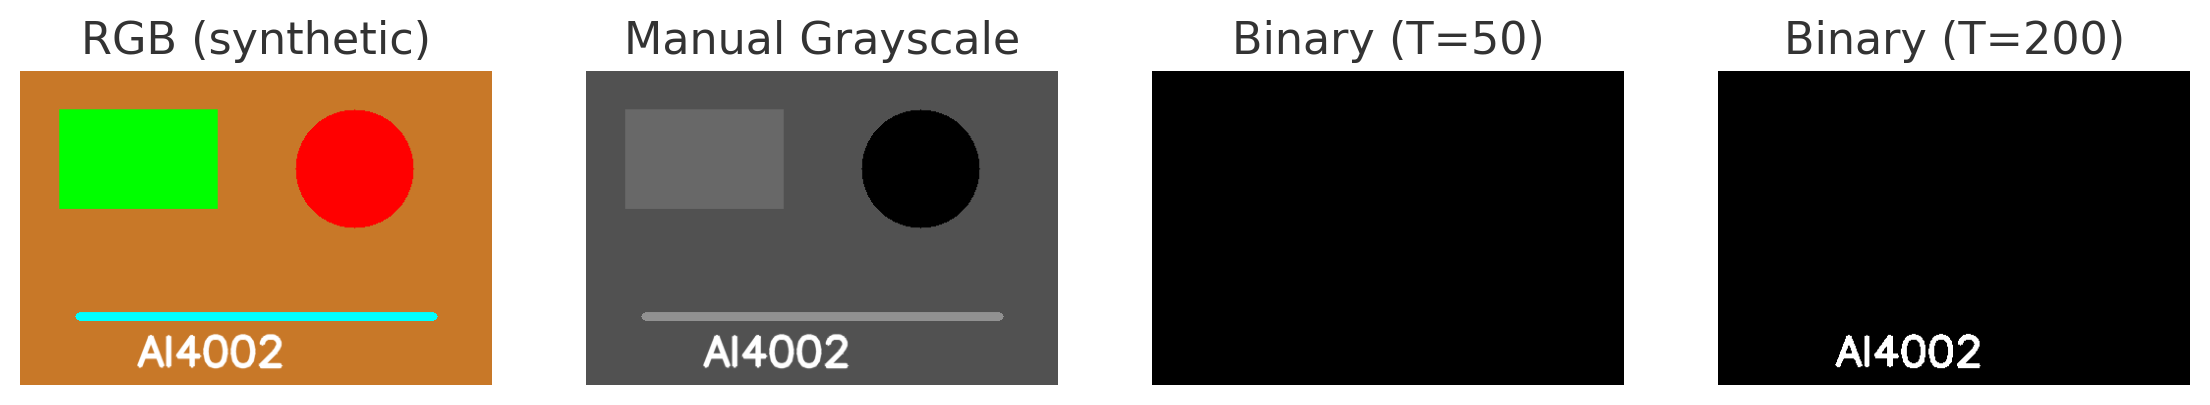

In [2]:

# Generate a synthetic RGB image with colorful shapes
H, W = 320, 480
rgb = np.zeros((H, W, 3), dtype=np.uint8)
rgb[:] = (40, 120, 200)  # BGR background (OpenCV uses BGR internally)

# Draw shapes (in BGR), then convert to RGB for display
cv2.rectangle(rgb, (40, 40), (200, 140), (0, 255, 0), -1)       # green rectangle
cv2.circle(rgb, (340, 100), 60, (0, 0, 255), -1)                # red circle
cv2.line(rgb, (60, 250), (420, 250), (255, 255, 0), 8)          # cyan line
cv2.putText(rgb, 'AI4002', (120, 300), cv2.FONT_HERSHEY_SIMPLEX, 1.4, (255, 255, 255), 3, cv2.LINE_AA)

# Convert from BGR to RGB for visualization consistency
rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)

# Manual grayscale conversion
R = rgb[...,0].astype(np.float64)
G = rgb[...,1].astype(np.float64)
B = rgb[...,2].astype(np.float64)
gray = 0.299*R + 0.587*G + 0.114*B
gray_u8 = to_uint8(gray)

# Manual binary thresholding with two thresholds
def binary_threshold(img_gray_u8, T):
    return (img_gray_u8 >= T).astype(np.uint8) * 255

binary_50  = binary_threshold(gray_u8, 50)
binary_200 = binary_threshold(gray_u8, 200)

# Visualize
show_images_row([rgb, gray_u8, binary_50, binary_200],
                titles=["RGB (synthetic)", "Manual Grayscale", "Binary (T=50)", "Binary (T=200)"],
                cmap_list=[None, 'gray', 'gray', 'gray'])


**Threshold effect:**
- Lower threshold (e.g., 50) turns more pixels white → brighter binary image.
- Higher threshold (e.g., 200) keeps only very bright pixels white → darker binary image.


## Q2: Intensity Transformations

**Tasks**
1. Power-law (gamma) transformation
2. Contrast stretching
3. Histogram equalization (manual)

**Concepts**
- `γ < 1` brightens dark pixels; `γ > 1` darkens them.
- Contrast stretching is linear mapping of [min,max]→[0,255].
- Histogram equalization is non-linear via CDF, redistributing intensities.


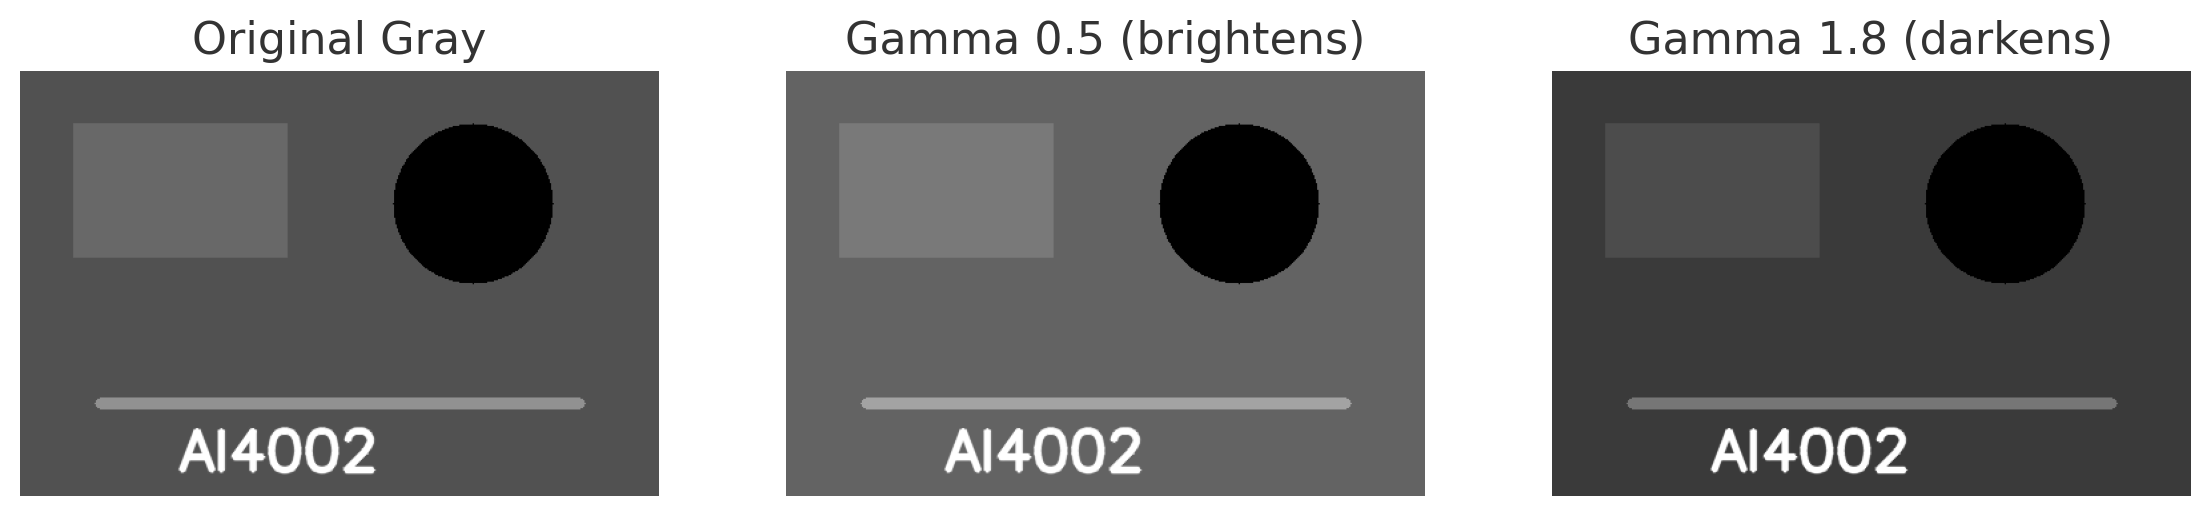

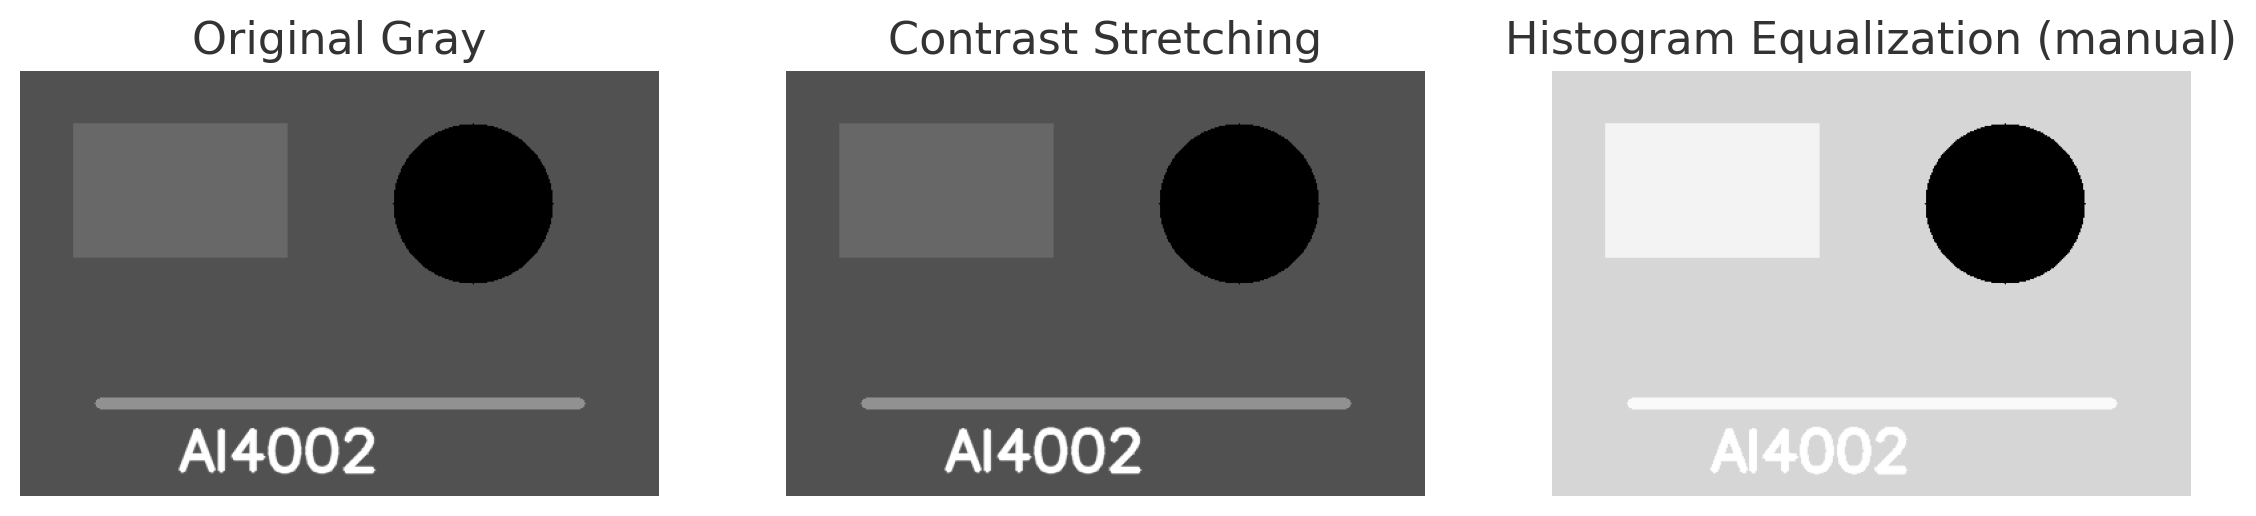

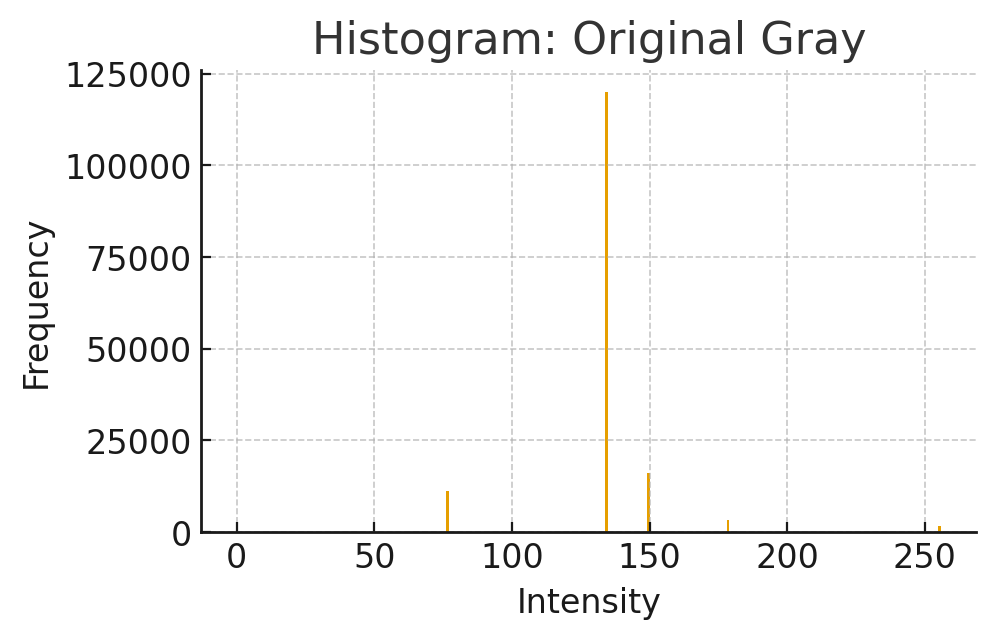

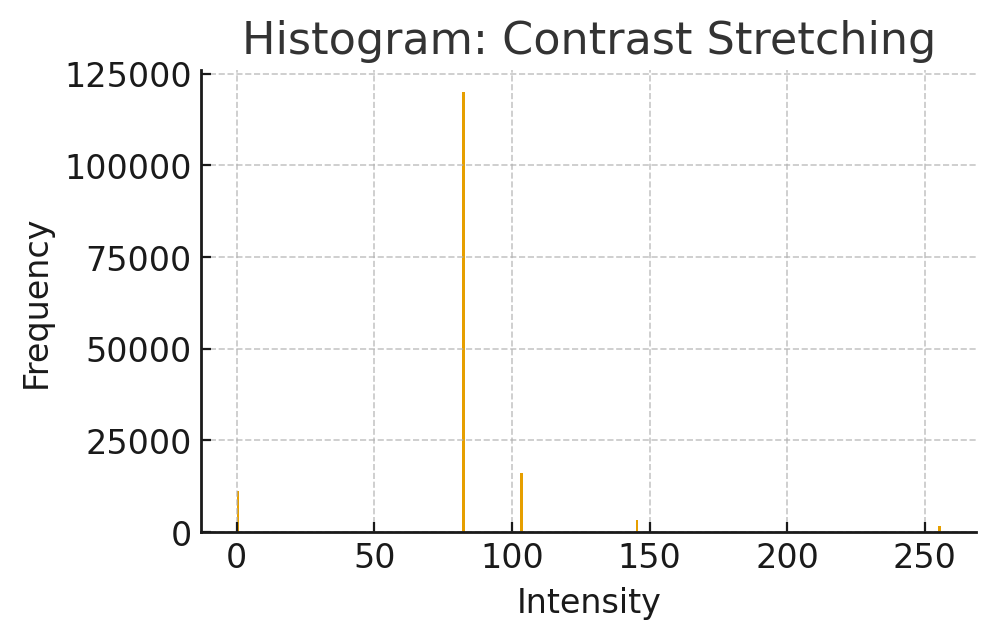

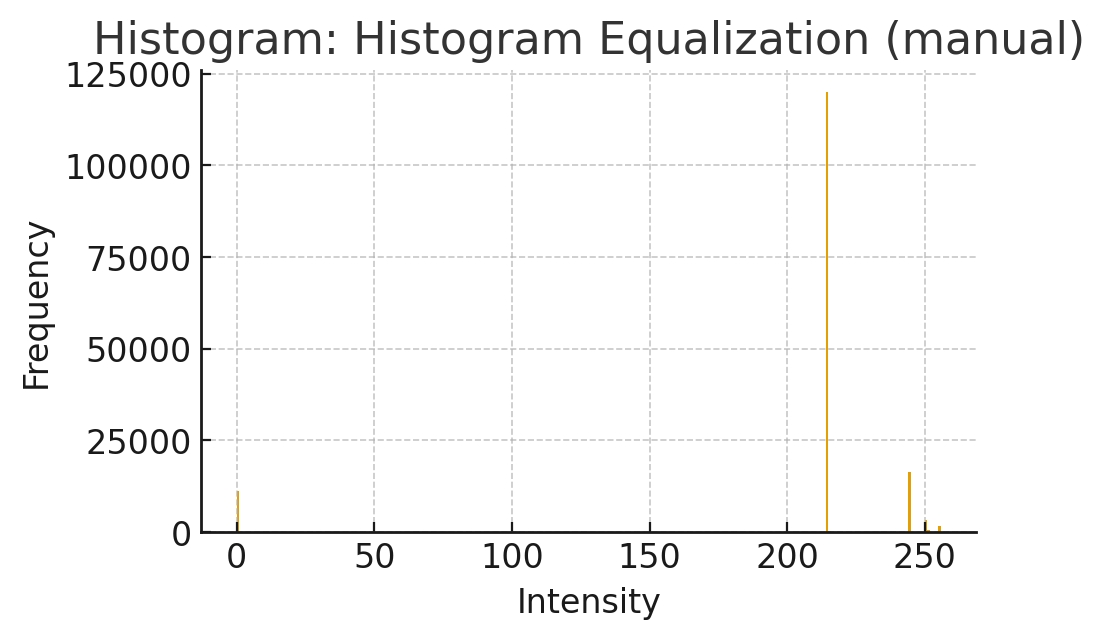

In [3]:

# Prepare grayscale in [0,1] for transformations
g = gray_u8.astype(np.float64) / 255.0

def power_law(img01, gamma, c=1.0):
    out = c * np.power(img01, gamma)
    return np.clip(out, 0, 1)

def contrast_stretch(img_u8):
    a = img_u8.min()
    b = img_u8.max()
    if b - a < 1:
        return np.zeros_like(img_u8)
    return ((img_u8 - a) * (255.0 / (b - a))).astype(np.uint8)

def hist_equalize_manual(img_u8):
    hist, _ = np.histogram(img_u8.flatten(), bins=256, range=(0,256))
    cdf = hist.cumsum()
    cdf_masked = np.ma.masked_equal(cdf, 0)
    cdf_min = cdf_masked.min()
    cdf_max = cdf_masked.max()
    cdf_eq = (cdf_masked - cdf_min) * 255.0 / (cdf_max - cdf_min)
    cdf_eq = np.ma.filled(cdf_eq, 0).astype(np.uint8)
    return cdf_eq[img_u8]

# Apply transforms
gamma_lt1 = power_law(g, gamma=0.5)
gamma_gt1 = power_law(g, gamma=1.8)
gamma_lt1_u8 = to_uint8(gamma_lt1 * 255)
gamma_gt1_u8 = to_uint8(gamma_gt1 * 255)

cs_u8 = contrast_stretch(gray_u8)
he_u8 = hist_equalize_manual(gray_u8)

# Visuals
show_images_row([gray_u8, gamma_lt1_u8, gamma_gt1_u8],
                titles=["Original Gray", "Gamma 0.5 (brightens)", "Gamma 1.8 (darkens)"],
                cmap_list=['gray','gray','gray'])

show_images_row([gray_u8, cs_u8, he_u8],
                titles=["Original Gray", "Contrast Stretching", "Histogram Equalization (manual)"],
                cmap_list=['gray','gray','gray'])

# Histograms
def plot_hist(img_u8, title):
    plt.figure(figsize=(5,3))
    plt.hist(img_u8.flatten(), bins=256, range=(0,256))
    plt.title(title)
    plt.xlabel("Intensity")
    plt.ylabel("Frequency")
    plt.show()

plot_hist(gray_u8, "Histogram: Original Gray")
plot_hist(cs_u8, "Histogram: Contrast Stretching")
plot_hist(he_u8, "Histogram: Histogram Equalization (manual)")


## Q3: Edge Detection using Gradient (Finite Difference)

**Tasks**
1. Implement forward finite differences Gx, Gy
2. Gradient magnitude and normalization
3. Compare with Sobel (manual & OpenCV)
4. Discuss noise and localization


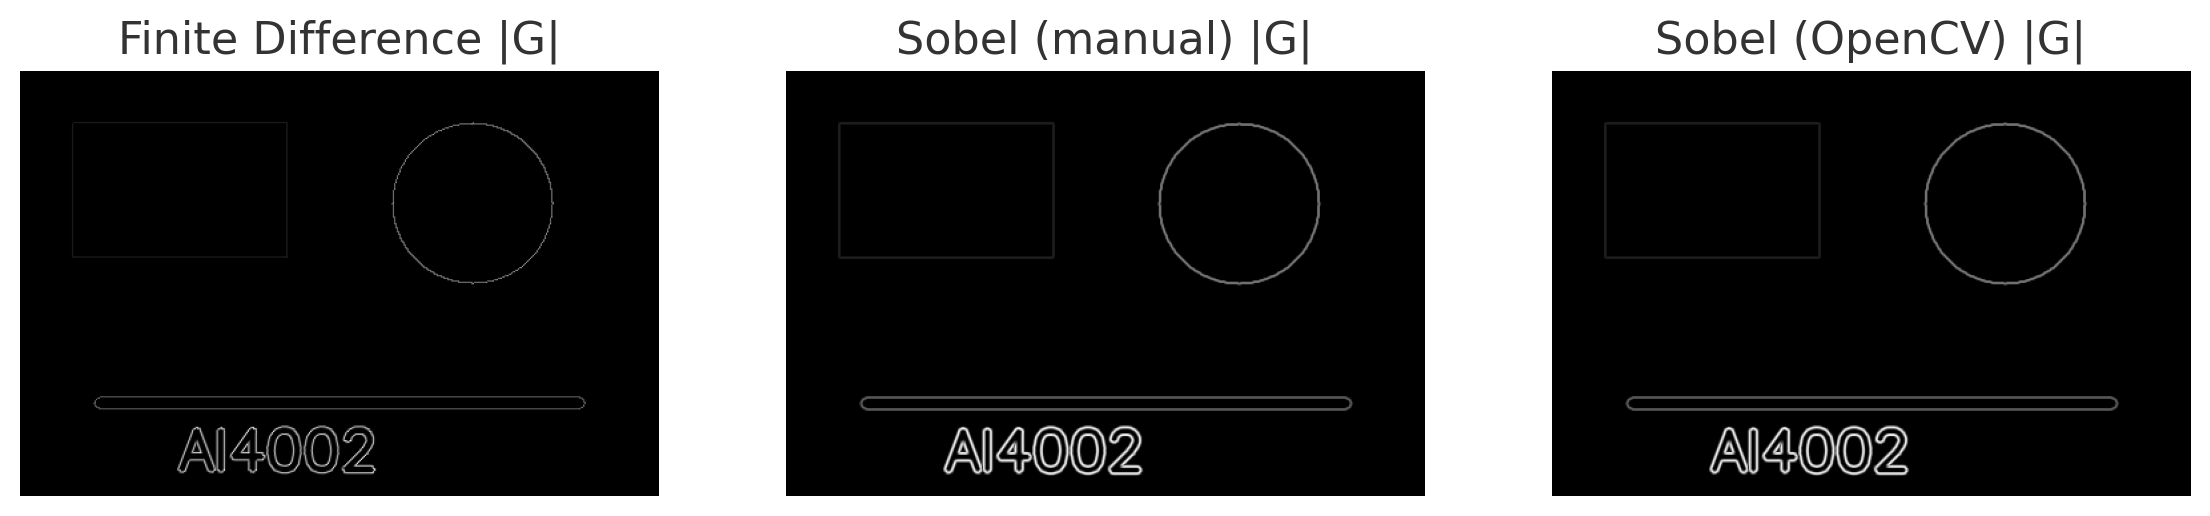

In [4]:

# Finite differences (forward difference)
f = gray_u8.astype(np.float64)

Gx_fd = np.zeros_like(f)
Gy_fd = np.zeros_like(f)
Gx_fd[:, :-1] = f[:, 1:] - f[:, :-1]
Gy_fd[:-1, :] = f[1:, :] - f[:-1, :]

grad_fd = np.sqrt(Gx_fd**2 + Gy_fd**2)
edge_fd = normalize_to_0_255(grad_fd)

# Sobel (manual)
sobel_gx = np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=np.float64)
sobel_gy = np.array([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=np.float64)
Gx_sobel = convolve2d(f, sobel_gx, padding='reflect')
Gy_sobel = convolve2d(f, sobel_gy, padding='reflect')
grad_sobel = np.sqrt(Gx_sobel**2 + Gy_sobel**2)
edge_sobel_manual = normalize_to_0_255(grad_sobel)

# OpenCV Sobel
Gx_cv = cv2.Sobel(gray_u8, cv2.CV_64F, 1, 0, ksize=3)
Gy_cv = cv2.Sobel(gray_u8, cv2.CV_64F, 0, 1, ksize=3)
edge_sobel_cv = normalize_to_0_255(np.sqrt(Gx_cv**2 + Gy_cv**2))

show_images_row([edge_fd, edge_sobel_manual, edge_sobel_cv],
                titles=["Finite Difference |G|", "Sobel (manual) |G|", "Sobel (OpenCV) |G|"],
                cmap_list=['gray','gray','gray'])


**Noise → false edges:** small random intensity changes create large local derivatives.

**Localization:** Sobel includes smoothing via 3×3 weighting → better localization and fewer spurious edges than 1-pixel finite difference.

## Q4: Denoising using Mean and Gaussian Smoothing

**Tasks**
1. Add Gaussian noise (mean=0, var=0.01)
2. Mean filters (3×3, 5×5) & Gaussian filters (3×3, 5×5, σ=1.0) — manual convolution
3. Discuss results and theory


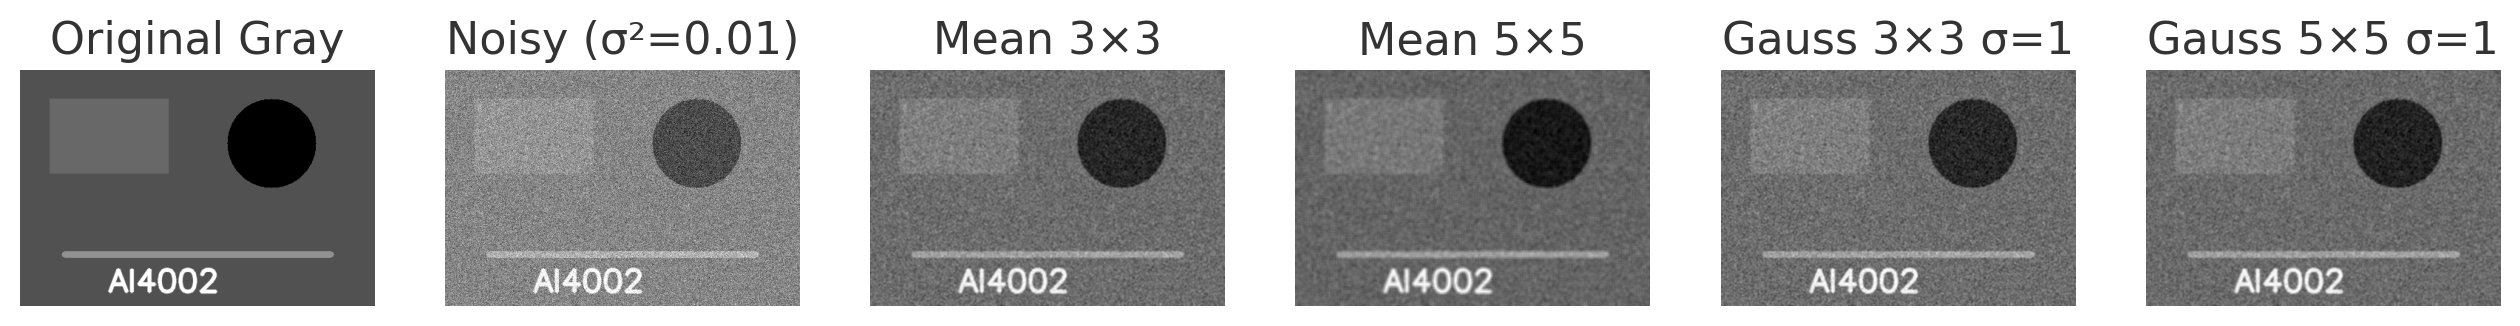

In [5]:

rng = np.random.default_rng(42)

# Add Gaussian noise in [0,1], variance = 0.01
g01 = gray_u8.astype(np.float64) / 255.0
noisy = g01 + rng.normal(0, np.sqrt(0.01), size=g01.shape)
noisy = np.clip(noisy, 0, 1)
noisy_u8 = to_uint8(noisy * 255)

# Mean filters
mean3 = mean_kernel(3)
mean5 = mean_kernel(5)

# Gaussian filters (sigma=1.0)
gauss3 = gaussian_kernel(3, sigma=1.0)
gauss5 = gaussian_kernel(5, sigma=1.0)

def apply_filter(img_u8, kernel):
    img = img_u8.astype(np.float64)
    out = convolve2d(img, kernel, padding='reflect')
    return to_uint8(out)

den_mean3 = apply_filter(noisy_u8, mean3)
den_mean5 = apply_filter(noisy_u8, mean5)
den_gauss3 = apply_filter(noisy_u8, gauss3)
den_gauss5 = apply_filter(noisy_u8, gauss5)

show_images_row([gray_u8, noisy_u8, den_mean3, den_mean5, den_gauss3, den_gauss5],
                titles=["Original Gray", "Noisy (σ²=0.01)", "Mean 3×3", "Mean 5×5", "Gauss 3×3 σ=1", "Gauss 5×5 σ=1"],
                cmap_list=['gray']*6, figsize=(16,4))


**Gaussian vs Mean:** Gaussian often better (center-weighted smoothing).  
**Larger kernels:** reduce noise more but blur edges more (averaging over wider area).  
**Gaussian preserves edges better:** non-uniform weights retain structure near edges more than uniform box.  
**When Mean is preferable:** simplicity/speed; hardware box-filter; as quick pre-smoother.  
**Sobel weights:** larger center weights emphasize axis-aligned gradient and add smoothing.

## Q5: Sobel Operator — Magnitude & Direction (Manual)

**Tasks**
1. Convolution with Sobel Gx/Gy
2. Edge magnitude and **direction**
3. Compare with finite difference


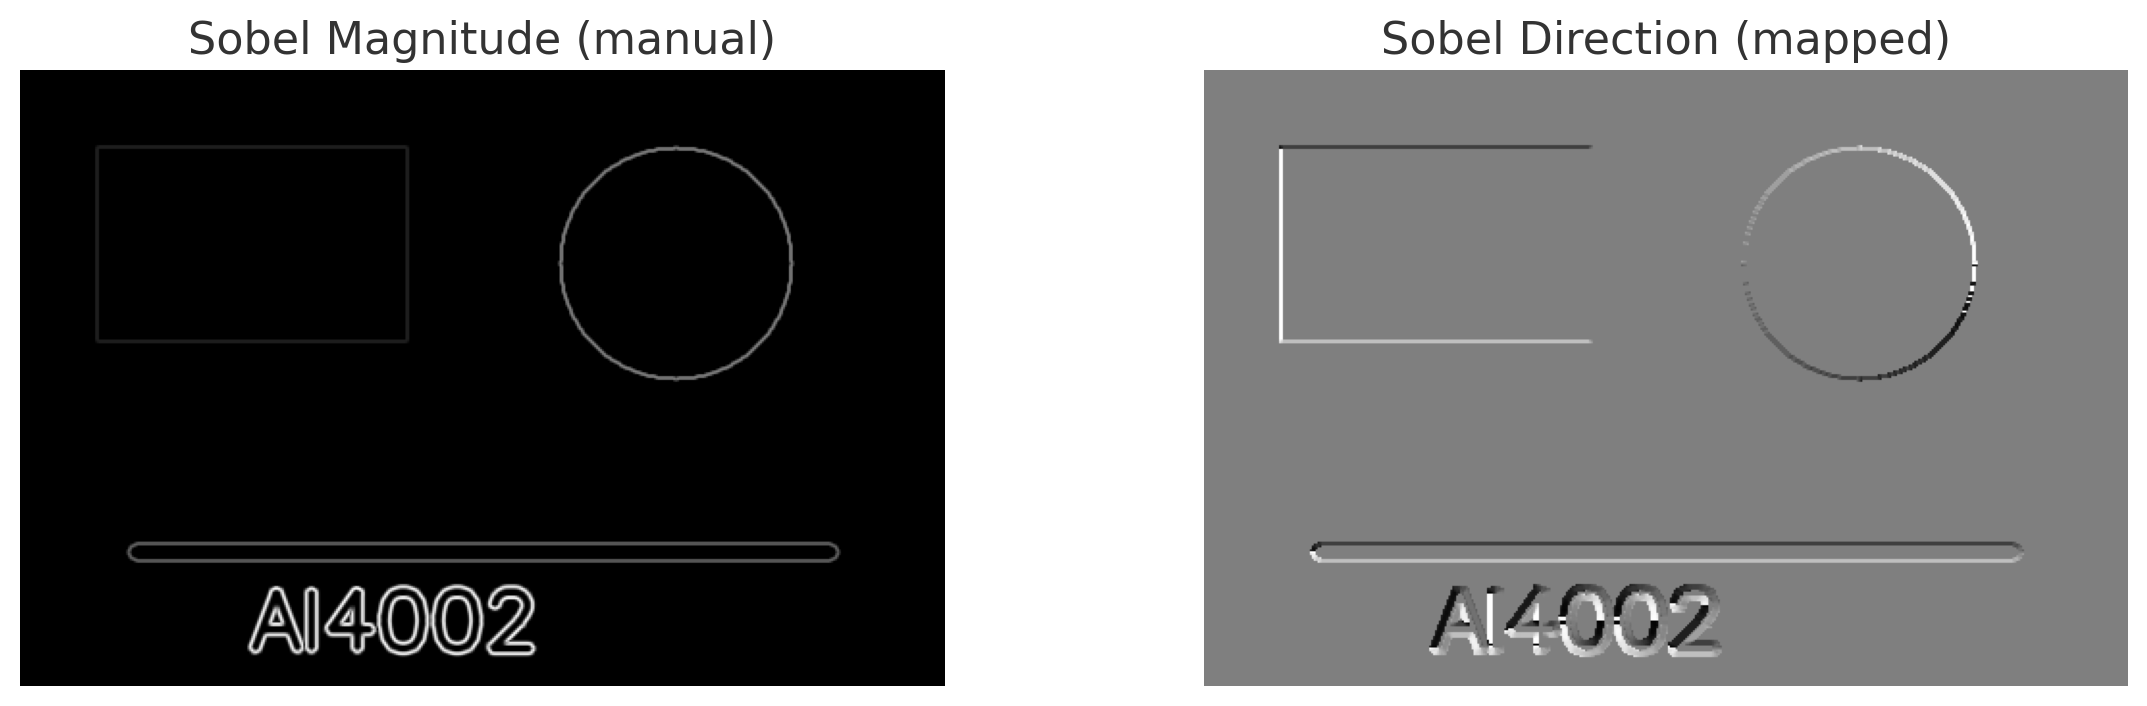

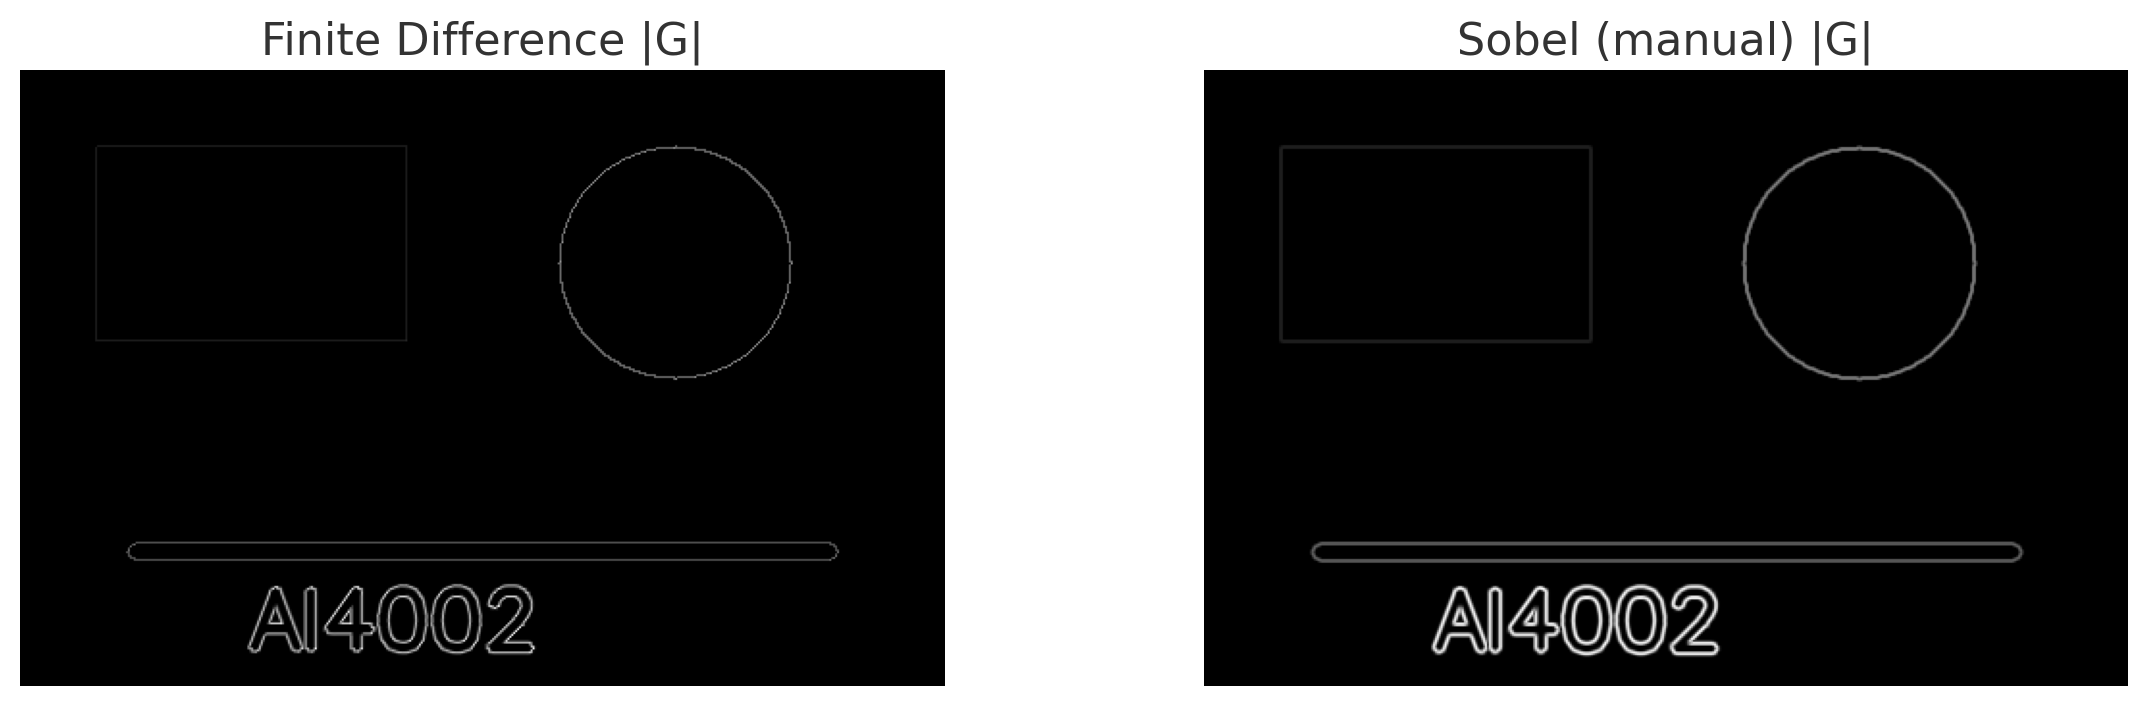

In [6]:

# From Q3
edge_mag = normalize_to_0_255(np.sqrt(Gx_sobel**2 + Gy_sobel**2))
edge_dir = np.arctan2(Gy_sobel, Gx_sobel)  # radians
edge_dir_disp = normalize_to_0_255((edge_dir + np.pi) / (2*np.pi))  # map to [0,255] for display

show_images_row([edge_mag, edge_dir_disp],
                titles=["Sobel Magnitude (manual)", "Sobel Direction (mapped)"],
                cmap_list=['gray','gray'])

show_images_row([edge_fd, edge_mag],
                titles=["Finite Difference |G|", "Sobel (manual) |G|"],
                cmap_list=['gray','gray'])


**Observation:** Sobel is smoother and less noisy than raw finite differences.

## Q6 (Bonus): Canny Edge Detector — Manual Pipeline

**Steps**
1) Gaussian smoothing, 2) Gradients (Sobel), 3) NMS, 4) Double threshold, 5) Hysteresis.  
Compare with `cv2.Canny` and answer why two thresholds, why NMS thins edges, how hysteresis helps.

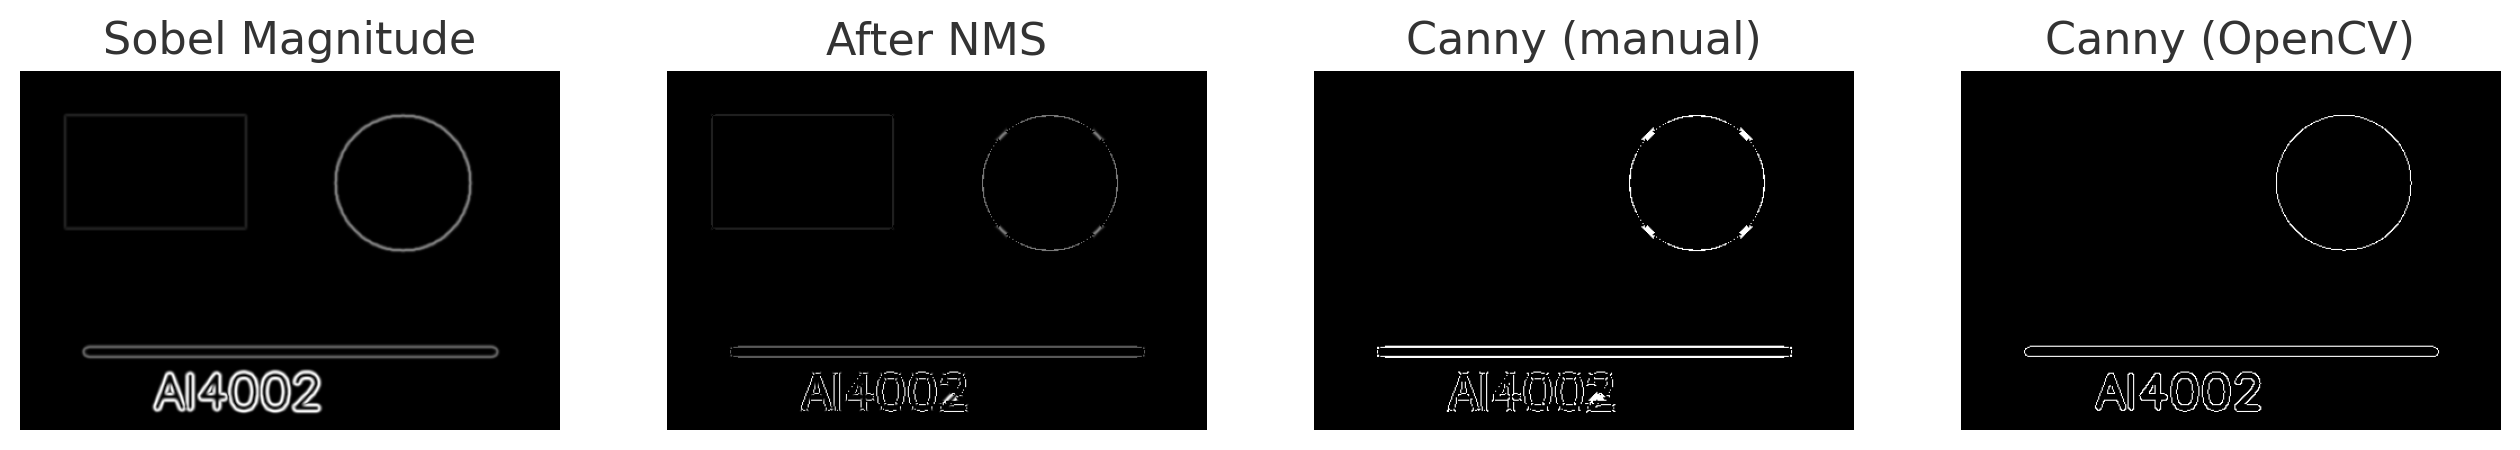

In [7]:

# 1) Smooth
smoothed = apply_filter(gray_u8, gaussian_kernel(5, 1.0)).astype(np.float64)

# 2) Gradients via Sobel
sobel_gx = np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=np.float64)
sobel_gy = np.array([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=np.float64)
Gx = convolve2d(smoothed, sobel_gx, padding='reflect')
Gy = convolve2d(smoothed, sobel_gy, padding='reflect')
mag = np.sqrt(Gx**2 + Gy**2)
ang = np.arctan2(Gy, Gx)

# 3) Non-maximum suppression
def nms(mag, ang):
    H, W = mag.shape
    Z = np.zeros((H,W), dtype=np.float64)
    angle = (np.degrees(ang) + 180) % 180
    for i in range(1, H-1):
        for j in range(1, W-1):
            q = 255; r = 255
            a = angle[i,j]
            if (0 <= a < 22.5) or (157.5 <= a < 180):
                q = mag[i, j+1]; r = mag[i, j-1]
            elif (22.5 <= a < 67.5):
                q = mag[i+1, j-1]; r = mag[i-1, j+1]
            elif (67.5 <= a < 112.5):
                q = mag[i+1, j]; r = mag[i-1, j]
            elif (112.5 <= a < 157.5):
                q = mag[i-1, j-1]; r = mag[i+1, j+1]
            if mag[i,j] >= q and mag[i,j] >= r:
                Z[i,j] = mag[i,j]
            else:
                Z[i,j] = 0
    return Z

nms_mag = nms(mag, ang)

# 4) Double threshold
high_ratio, low_ratio = 0.15, 0.05
high_thresh = nms_mag.max() * high_ratio
low_thresh = nms_mag.max() * low_ratio

strong = 255
weak = 50
res = np.zeros_like(nms_mag, dtype=np.uint8)
strong_i, strong_j = np.where(nms_mag >= high_thresh)
weak_i, weak_j = np.where((nms_mag >= low_thresh) & (nms_mag < high_thresh))
res[strong_i, strong_j] = strong
res[weak_i, weak_j] = weak

# 5) Hysteresis
def hysteresis(img, weak=50, strong=255):
    H, W = img.shape
    out = img.copy()
    for i in range(1, H-1):
        for j in range(1, W-1):
            if out[i,j] == weak:
                if np.any(out[i-1:i+2, j-1:j+2] == strong):
                    out[i,j] = strong
                else:
                    out[i,j] = 0
    return out

edges_canny_manual = hysteresis(res, weak=weak, strong=strong)

# OpenCV comparison
edges_cv = cv2.Canny(gray_u8, 100, 200)

show_images_row([normalize_to_0_255(mag), normalize_to_0_255(nms_mag), edges_canny_manual, edges_cv],
                titles=["Sobel Magnitude", "After NMS", "Canny (manual)", "Canny (OpenCV)"],
                cmap_list=['gray','gray','gray','gray'], figsize=(16,4))


**Why two thresholds?** High selects reliable strong edges; low keeps weak edges connected to strong ones.
**Why NMS thins edges?** Keeps only local maxima along gradient direction.
**How hysteresis helps?** Links weak edges to strong neighbors; removes isolated weak noise.